# Chapter 11.1: Offline Evaluation Deep Dive

## Learning Objectives

By the end of this notebook, you will be able to:

1. **Implement ranking metrics** (NDCG@K, MAP@K, MRR, HitRate@K) from scratch and understand their edge cases
2. **Compute beyond-accuracy metrics** including Coverage, Diversity (ILD), Novelty, and Serendipity
3. **Measure popularity concentration** using Catalog Coverage and the Gini Index
4. **Design proper evaluation protocols** including leave-one-out, temporal split, and k-fold for recommendation
5. **Apply statistical significance testing** (paired t-test, Wilcoxon signed-rank) to compare recommender systems
6. **Build a comprehensive offline evaluation framework** that combines all metrics into a single reusable pipeline
7. **Identify and handle edge cases** in metric computation (empty recommendation lists, cold-start users, etc.)

## Prerequisites

- Familiarity with basic recommendation system concepts (collaborative filtering, content-based filtering)
- Python proficiency (NumPy, pandas, matplotlib)
- Basic understanding of information retrieval metrics
- Introductory statistics (hypothesis testing, p-values)

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/hideak1/rec_system/blob/main/notebooks/part11/chapter_11.1_offline_eval.ipynb)
[![Download](https://img.shields.io/badge/Download-Notebook-blue)](https://raw.githubusercontent.com/hideak1/rec_system/main/notebooks/part11/chapter_11.1_offline_eval.ipynb)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import defaultdict
from scipy import stats
from itertools import combinations

np.random.seed(42)
plt.style.use('seaborn-v0_8')
print("All imports successful.")

All imports successful.


## 1. Generating Synthetic Recommendation Data

We simulate a scenario with users, items, ground-truth relevance, and two recommendation models (Model A and Model B) that each produce a ranked list of items per user.

In [2]:
# --- Synthetic data generation ---
NUM_USERS = 200
NUM_ITEMS = 500
K = 10  # evaluation cutoff

rng = np.random.RandomState(42)

# Ground truth: each user has 5-20 relevant items
ground_truth = {}
for u in range(NUM_USERS):
    n_rel = rng.randint(5, 21)
    ground_truth[u] = set(rng.choice(NUM_ITEMS, size=n_rel, replace=False))

# Item popularity (Zipf-like)
item_popularity = np.zeros(NUM_ITEMS)
for u in ground_truth:
    for i in ground_truth[u]:
        item_popularity[i] += 1
item_popularity /= item_popularity.sum()

# Model A: reasonably good, slightly popularity-biased
# Model B: slightly worse ranking but more diverse
def generate_recommendations(ground_truth, num_items, k, quality, diversity_noise, rng):
    recs = {}
    for u, relevant in ground_truth.items():
        scores = rng.uniform(0, 0.3, size=num_items)
        for i in relevant:
            if rng.random() < quality:
                scores[i] += rng.uniform(0.5, 1.0)
        scores += rng.normal(0, diversity_noise, size=num_items)
        top_k = np.argsort(-scores)[:k]
        recs[u] = list(top_k)
    return recs

recs_A = generate_recommendations(ground_truth, NUM_ITEMS, K, quality=0.7, diversity_noise=0.1, rng=np.random.RandomState(1))
recs_B = generate_recommendations(ground_truth, NUM_ITEMS, K, quality=0.55, diversity_noise=0.4, rng=np.random.RandomState(2))

print(f"Users: {NUM_USERS}, Items: {NUM_ITEMS}, K: {K}")
print(f"Example ground truth for user 0: {sorted(list(ground_truth[0]))[:10]}...")
print(f"Model A recs for user 0: {recs_A[0]}")
print(f"Model B recs for user 0: {recs_B[0]}")

Users: 200, Items: 500, K: 10
Example ground truth for user 0: [9, 68, 73, 104, 124, 155, 362, 375, 378, 395]...
Model A recs for user 0: [362, 155, 378, 395, 68, 104, 451, 9, 375, 163]
Model B recs for user 0: [375, 451, 162, 335, 374, 411, 114, 267, 395, 353]


## 2. Ranking Metrics: NDCG@K, MAP@K, MRR, HitRate@K

### 2.1 Hit Rate @ K

The simplest metric: did at least one relevant item appear in the top-K?

$$\text{HitRate@K} = \frac{1}{|U|} \sum_{u \in U} \mathbb{1}\left[|\text{Rec}_u(K) \cap \text{Rel}_u| > 0\right]$$

> **💡 Concept:** HitRate@K is often used in leave-one-out evaluation where each user has exactly one test item. It answers: "Can the system place the relevant item in the top-K?"

In [3]:
def hit_rate_at_k(recommendations, ground_truth, k):
    """Compute Hit Rate @ K."""
    hits = 0
    n_users = 0
    for u, rec_list in recommendations.items():
        if u not in ground_truth or len(ground_truth[u]) == 0:
            continue  # skip users with no ground truth
        n_users += 1
        top_k = rec_list[:k]
        if len(set(top_k) & ground_truth[u]) > 0:
            hits += 1
    return hits / n_users if n_users > 0 else 0.0

for k_val in [1, 5, 10]:
    hr_a = hit_rate_at_k(recs_A, ground_truth, k_val)
    hr_b = hit_rate_at_k(recs_B, ground_truth, k_val)
    print(f"HitRate@{k_val}  Model A: {hr_a:.4f}  Model B: {hr_b:.4f}")

HitRate@1  Model A: 1.0000  Model B: 0.6250
HitRate@5  Model A: 1.0000  Model B: 0.8900
HitRate@10  Model A: 1.0000  Model B: 0.9350


### 2.2 Mean Reciprocal Rank (MRR)

MRR considers the rank position of the *first* relevant item:

$$\text{MRR} = \frac{1}{|U|} \sum_{u \in U} \frac{1}{\text{rank}_u}$$

where $\text{rank}_u$ is the position of the first relevant item in the recommendation list for user $u$ (or $\infty$ if no relevant item is present).

> **⚠️ Common Pitfall:** MRR only cares about the first relevant item. If your use case requires surfacing *multiple* relevant items (e.g., a playlist), MRR will not capture that.

In [4]:
def mrr_at_k(recommendations, ground_truth, k):
    """Compute Mean Reciprocal Rank @ K."""
    rr_sum = 0.0
    n_users = 0
    for u, rec_list in recommendations.items():
        if u not in ground_truth or len(ground_truth[u]) == 0:
            continue
        n_users += 1
        for rank, item in enumerate(rec_list[:k], start=1):
            if item in ground_truth[u]:
                rr_sum += 1.0 / rank
                break
    return rr_sum / n_users if n_users > 0 else 0.0

print(f"MRR@10  Model A: {mrr_at_k(recs_A, ground_truth, 10):.4f}")
print(f"MRR@10  Model B: {mrr_at_k(recs_B, ground_truth, 10):.4f}")

MRR@10  Model A: 1.0000
MRR@10  Model B: 0.7368


### 2.3 MAP@K (Mean Average Precision)

Average Precision rewards placing relevant items at higher positions and considers *all* relevant items:

$$\text{AP@K}(u) = \frac{1}{\min(|\text{Rel}_u|, K)} \sum_{k=1}^{K} \text{Precision@k} \cdot \text{rel}(k)$$

$$\text{MAP@K} = \frac{1}{|U|} \sum_{u \in U} \text{AP@K}(u)$$

> **🔑 Pro Tip:** The denominator uses $\min(|\text{Rel}_u|, K)$ to ensure AP is not penalised when a user has more relevant items than $K$.

In [5]:
def average_precision_at_k(rec_list, relevant_set, k):
    """Compute AP@K for a single user."""
    if not relevant_set:
        return 0.0
    hits = 0
    sum_prec = 0.0
    for i, item in enumerate(rec_list[:k], start=1):
        if item in relevant_set:
            hits += 1
            sum_prec += hits / i
    return sum_prec / min(len(relevant_set), k)


def map_at_k(recommendations, ground_truth, k):
    """Compute MAP@K across all users."""
    ap_scores = []
    for u, rec_list in recommendations.items():
        if u not in ground_truth or len(ground_truth[u]) == 0:
            continue
        ap_scores.append(average_precision_at_k(rec_list, ground_truth[u], k))
    return np.mean(ap_scores) if ap_scores else 0.0

print(f"MAP@10  Model A: {map_at_k(recs_A, ground_truth, 10):.4f}")
print(f"MAP@10  Model B: {map_at_k(recs_B, ground_truth, 10):.4f}")

MAP@10  Model A: 0.8248
MAP@10  Model B: 0.1887


### 2.4 NDCG@K (Normalized Discounted Cumulative Gain)

NDCG uses a logarithmic discount to weigh items at lower positions less:

$$\text{DCG@K} = \sum_{i=1}^{K} \frac{\text{rel}_i}{\log_2(i+1)}$$

$$\text{NDCG@K} = \frac{\text{DCG@K}}{\text{IDCG@K}}$$

where IDCG@K is the ideal DCG obtained by sorting items by true relevance.

> **💡 Concept:** NDCG supports graded relevance (e.g., relevance = 0, 1, 2, 3), not just binary. This is useful when you have explicit ratings or multi-level engagement signals.

In [6]:
def dcg_at_k(relevances, k):
    """Compute DCG@K given a list of relevance scores."""
    relevances = np.array(relevances[:k], dtype=np.float64)
    if len(relevances) == 0:
        return 0.0
    discounts = np.log2(np.arange(2, len(relevances) + 2))
    return np.sum(relevances / discounts)


def ndcg_at_k(rec_list, relevant_set, k):
    """Compute NDCG@K for a single user (binary relevance)."""
    relevances = [1.0 if item in relevant_set else 0.0 for item in rec_list[:k]]
    dcg = dcg_at_k(relevances, k)
    # Ideal: all relevant items at the top
    ideal_rels = sorted(relevances, reverse=True)
    # But ideal should consider all available relevant items
    n_rel = min(len(relevant_set), k)
    ideal_rels = [1.0] * n_rel + [0.0] * (k - n_rel)
    idcg = dcg_at_k(ideal_rels, k)
    return dcg / idcg if idcg > 0 else 0.0


def mean_ndcg_at_k(recommendations, ground_truth, k):
    """Compute mean NDCG@K across all users."""
    scores = []
    for u, rec_list in recommendations.items():
        if u not in ground_truth or len(ground_truth[u]) == 0:
            continue
        scores.append(ndcg_at_k(rec_list, ground_truth[u], k))
    return np.mean(scores) if scores else 0.0

print(f"NDCG@10  Model A: {mean_ndcg_at_k(recs_A, ground_truth, 10):.4f}")
print(f"NDCG@10  Model B: {mean_ndcg_at_k(recs_B, ground_truth, 10):.4f}")

NDCG@10  Model A: 0.8814
NDCG@10  Model B: 0.3406


### Visualising Metric Comparison Across K Values

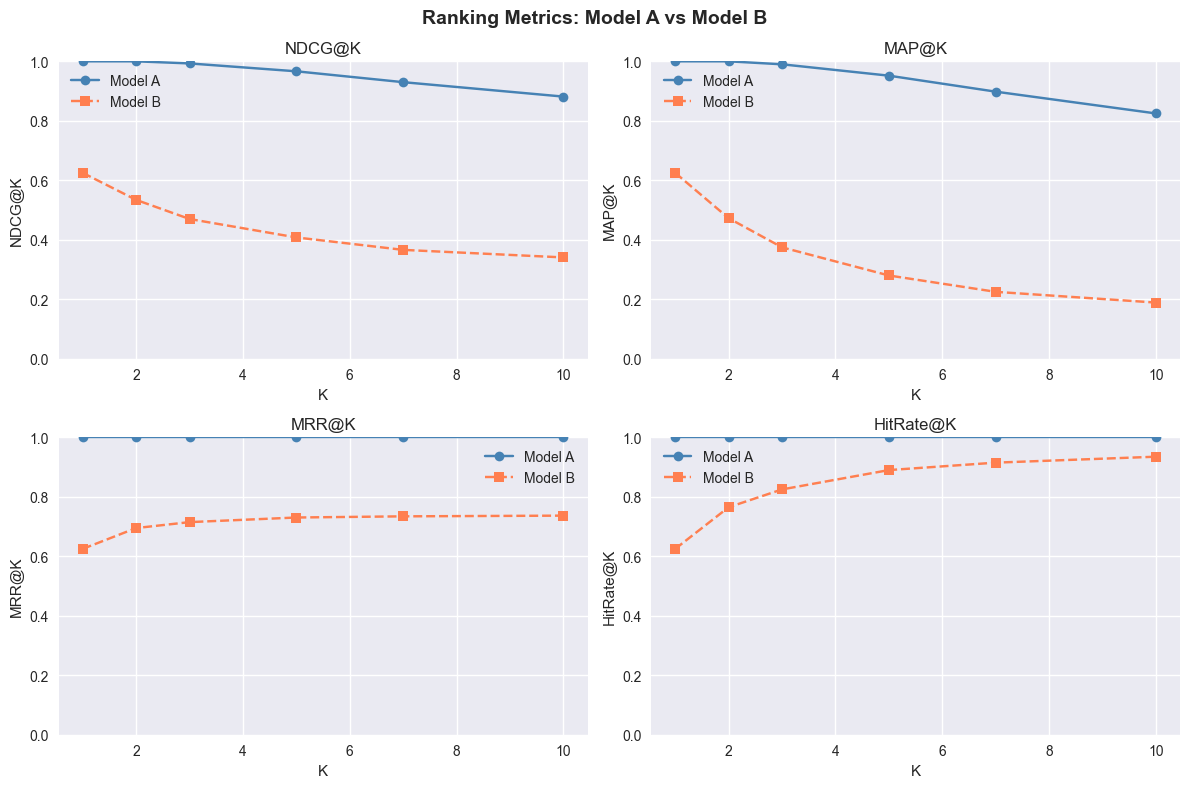

In [7]:
k_values = [1, 2, 3, 5, 7, 10]
metrics_A = {'NDCG': [], 'MAP': [], 'MRR': [], 'HitRate': []}
metrics_B = {'NDCG': [], 'MAP': [], 'MRR': [], 'HitRate': []}

for k_val in k_values:
    metrics_A['NDCG'].append(mean_ndcg_at_k(recs_A, ground_truth, k_val))
    metrics_A['MAP'].append(map_at_k(recs_A, ground_truth, k_val))
    metrics_A['MRR'].append(mrr_at_k(recs_A, ground_truth, k_val))
    metrics_A['HitRate'].append(hit_rate_at_k(recs_A, ground_truth, k_val))
    metrics_B['NDCG'].append(mean_ndcg_at_k(recs_B, ground_truth, k_val))
    metrics_B['MAP'].append(map_at_k(recs_B, ground_truth, k_val))
    metrics_B['MRR'].append(mrr_at_k(recs_B, ground_truth, k_val))
    metrics_B['HitRate'].append(hit_rate_at_k(recs_B, ground_truth, k_val))

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for idx, metric_name in enumerate(['NDCG', 'MAP', 'MRR', 'HitRate']):
    ax = axes[idx // 2][idx % 2]
    ax.plot(k_values, metrics_A[metric_name], 'o-', label='Model A', color='steelblue')
    ax.plot(k_values, metrics_B[metric_name], 's--', label='Model B', color='coral')
    ax.set_xlabel('K')
    ax.set_ylabel(f'{metric_name}@K')
    ax.set_title(f'{metric_name}@K')
    ax.legend()
    ax.set_ylim(0, 1)

plt.suptitle('Ranking Metrics: Model A vs Model B', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 3. Beyond-Accuracy Metrics

Accuracy alone does not make a good recommender. We also care about:

| Metric | What it measures |
|--------|------------------|
| **Coverage** | What fraction of the catalog is recommended |
| **Diversity (ILD)** | How different are items within a single recommendation list |
| **Novelty** | How unexpected/niche are the recommended items |
| **Serendipity** | Relevant items the user would not have found on their own |

Reference: Kaminskas & Bridge, "Diversity, Serendipity, Novelty, and Coverage: A Survey and Empirical Analysis of Beyond-Accuracy Objectives in Recommender Systems" (2016).

In [8]:
# --- Coverage ---
def catalog_coverage(recommendations, num_items, k):
    """Fraction of the catalog that appears in any user's top-K."""
    recommended_items = set()
    for rec_list in recommendations.values():
        recommended_items.update(rec_list[:k])
    return len(recommended_items) / num_items

# --- Gini Index for popularity concentration ---
def gini_index(recommendations, num_items, k):
    """Gini index of item recommendation frequency. 0 = perfect equality, 1 = maximum inequality."""
    counts = np.zeros(num_items)
    for rec_list in recommendations.values():
        for item in rec_list[:k]:
            counts[item] += 1
    counts = np.sort(counts)
    n = len(counts)
    index = np.arange(1, n + 1)
    return (2 * np.sum(index * counts) / (n * np.sum(counts))) - (n + 1) / n

print(f"Catalog Coverage@10  Model A: {catalog_coverage(recs_A, NUM_ITEMS, 10):.4f}")
print(f"Catalog Coverage@10  Model B: {catalog_coverage(recs_B, NUM_ITEMS, 10):.4f}")
print(f"Gini Index@10       Model A: {gini_index(recs_A, NUM_ITEMS, 10):.4f}")
print(f"Gini Index@10       Model B: {gini_index(recs_B, NUM_ITEMS, 10):.4f}")

Catalog Coverage@10  Model A: 0.9800
Catalog Coverage@10  Model B: 0.9800
Gini Index@10       Model A: 0.2742
Gini Index@10       Model B: 0.2789


In [9]:
# --- Diversity (Intra-List Distance) ---
# We create a synthetic item feature matrix for distance computation
item_features = rng.randn(NUM_ITEMS, 20)
# Normalise for cosine distance
item_features = item_features / np.linalg.norm(item_features, axis=1, keepdims=True)

def intra_list_diversity(rec_list, item_features, k):
    """Average pairwise cosine distance within the top-K list."""
    items = rec_list[:k]
    if len(items) < 2:
        return 0.0
    feats = item_features[items]
    # Cosine similarity matrix
    sim_matrix = feats @ feats.T
    n = len(items)
    # Average pairwise distance (1 - similarity)
    total_dist = 0.0
    count = 0
    for i in range(n):
        for j in range(i + 1, n):
            total_dist += 1.0 - sim_matrix[i, j]
            count += 1
    return total_dist / count

def mean_diversity(recommendations, item_features, k):
    divs = [intra_list_diversity(rec, item_features, k) for rec in recommendations.values()]
    return np.mean(divs)

# --- Novelty ---
def mean_novelty(recommendations, item_popularity, k):
    """Average self-information of recommended items. Higher = more novel (less popular)."""
    novelties = []
    for rec_list in recommendations.values():
        item_novs = []
        for item in rec_list[:k]:
            pop = item_popularity[item]
            if pop > 0:
                item_novs.append(-np.log2(pop))
            else:
                item_novs.append(0.0)  # unseen item
        novelties.append(np.mean(item_novs))
    return np.mean(novelties)

print(f"Diversity (ILD)@10  Model A: {mean_diversity(recs_A, item_features, 10):.4f}")
print(f"Diversity (ILD)@10  Model B: {mean_diversity(recs_B, item_features, 10):.4f}")
print(f"Novelty@10          Model A: {mean_novelty(recs_A, item_popularity, 10):.4f}")
print(f"Novelty@10          Model B: {mean_novelty(recs_B, item_popularity, 10):.4f}")

Diversity (ILD)@10  Model A: 0.9992
Diversity (ILD)@10  Model B: 1.0052
Novelty@10          Model A: 8.8683
Novelty@10          Model B: 9.0141


### Accuracy vs. Beyond-Accuracy Trade-off Visualization

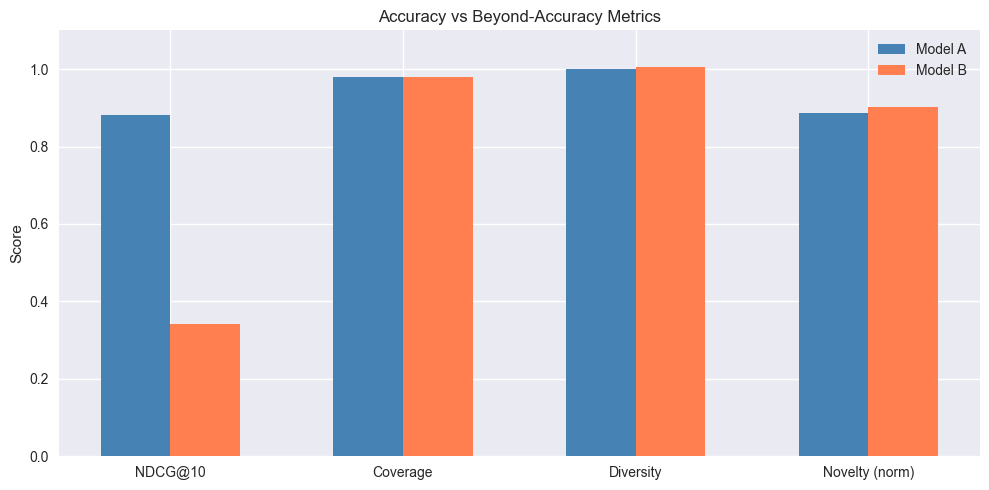

In [10]:
results = {
    'NDCG@10': [mean_ndcg_at_k(recs_A, ground_truth, 10), mean_ndcg_at_k(recs_B, ground_truth, 10)],
    'Coverage': [catalog_coverage(recs_A, NUM_ITEMS, 10), catalog_coverage(recs_B, NUM_ITEMS, 10)],
    'Diversity': [mean_diversity(recs_A, item_features, 10), mean_diversity(recs_B, item_features, 10)],
    'Novelty (norm)': [
        mean_novelty(recs_A, item_popularity, 10) / 10.0,
        mean_novelty(recs_B, item_popularity, 10) / 10.0
    ],
}

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(results))
width = 0.3
ax.bar(x - width/2, [v[0] for v in results.values()], width, label='Model A', color='steelblue')
ax.bar(x + width/2, [v[1] for v in results.values()], width, label='Model B', color='coral')
ax.set_xticks(x)
ax.set_xticklabels(results.keys())
ax.set_ylabel('Score')
ax.set_title('Accuracy vs Beyond-Accuracy Metrics')
ax.legend()
ax.set_ylim(0, 1.1)
plt.tight_layout()
plt.show()

## 4. Evaluation Protocols

### 4.1 Leave-One-Out

For each user, hold out *one* interaction as the test item; use the rest for training.

### 4.2 Temporal Split

Split data by timestamp: everything before time $t$ is training, everything after is test. This prevents data leakage and mimics real deployment.

### 4.3 K-Fold for Recommendations

Randomly partition user-item interactions into $k$ folds. Typically fold by *users* (not interactions) to avoid train/test contamination.

> **⚠️ Common Pitfall:** Random splitting can leak future information. Always prefer temporal splits for production evaluation. Random splits are acceptable only for research comparisons on static datasets.

In [11]:
# Demonstrate temporal split on synthetic interaction data
n_interactions = 5000
interactions = pd.DataFrame({
    'user_id': rng.randint(0, NUM_USERS, n_interactions),
    'item_id': rng.randint(0, NUM_ITEMS, n_interactions),
    'timestamp': pd.date_range('2024-01-01', periods=n_interactions, freq='5min'),
    'rating': rng.choice([1, 2, 3, 4, 5], n_interactions, p=[0.05, 0.1, 0.2, 0.35, 0.3])
})

# --- Temporal Split ---
split_time = interactions['timestamp'].quantile(0.8)
train_temporal = interactions[interactions['timestamp'] <= split_time]
test_temporal = interactions[interactions['timestamp'] > split_time]
print(f"Temporal split: train={len(train_temporal)}, test={len(test_temporal)}")
print(f"Train period: {train_temporal['timestamp'].min()} to {train_temporal['timestamp'].max()}")
print(f"Test period:  {test_temporal['timestamp'].min()} to {test_temporal['timestamp'].max()}")

# --- Leave-One-Out ---
# For each user, hold out the last interaction
interactions_sorted = interactions.sort_values('timestamp')
test_loo = interactions_sorted.groupby('user_id').tail(1)
train_loo = interactions_sorted.drop(test_loo.index)
print(f"\nLeave-one-out: train={len(train_loo)}, test={len(test_loo)}")

# --- K-Fold by User ---
unique_users = interactions['user_id'].unique()
rng.shuffle(unique_users)
n_folds = 5
folds = np.array_split(unique_users, n_folds)
for i, fold_users in enumerate(folds):
    test_fold = interactions[interactions['user_id'].isin(fold_users)]
    train_fold = interactions[~interactions['user_id'].isin(fold_users)]
    print(f"Fold {i+1}: train_users={len(unique_users)-len(fold_users)}, test_users={len(fold_users)}, "
          f"train_ints={len(train_fold)}, test_ints={len(test_fold)}")

Temporal split: train=4000, test=1000
Train period: 2024-01-01 00:00:00 to 2024-01-14 21:15:00
Test period:  2024-01-14 21:20:00 to 2024-01-18 08:35:00

Leave-one-out: train=4800, test=200
Fold 1: train_users=160, test_users=40, train_ints=4019, test_ints=981
Fold 2: train_users=160, test_users=40, train_ints=4034, test_ints=966
Fold 3: train_users=160, test_users=40, train_ints=3999, test_ints=1001
Fold 4: train_users=160, test_users=40, train_ints=3976, test_ints=1024
Fold 5: train_users=160, test_users=40, train_ints=3972, test_ints=1028


## 5. Statistical Significance Testing

When comparing two models, we need to know if the difference in metrics is *statistically significant* or just noise.

### Paired t-test

Assumes the per-user metric differences are approximately normally distributed.

### Wilcoxon Signed-Rank Test

Non-parametric alternative — makes no normality assumption. Preferred when per-user metric distributions are skewed (which they often are in recommendation).

Reference: Urbano et al., "Statistical Significance Testing in Information Retrieval: An Empirical Analysis of Type I, Type II, and Type III Errors" (SIGIR 2019).

In [12]:
# Compute per-user NDCG@10 for both models
per_user_ndcg_A = []
per_user_ndcg_B = []
common_users = sorted(set(recs_A.keys()) & set(recs_B.keys()) & set(ground_truth.keys()))

for u in common_users:
    if len(ground_truth[u]) == 0:
        continue
    per_user_ndcg_A.append(ndcg_at_k(recs_A[u], ground_truth[u], 10))
    per_user_ndcg_B.append(ndcg_at_k(recs_B[u], ground_truth[u], 10))

per_user_ndcg_A = np.array(per_user_ndcg_A)
per_user_ndcg_B = np.array(per_user_ndcg_B)

# Paired t-test
t_stat, t_pvalue = stats.ttest_rel(per_user_ndcg_A, per_user_ndcg_B)
print(f"Paired t-test:  t={t_stat:.4f}, p={t_pvalue:.6f}")

# Wilcoxon signed-rank test
w_stat, w_pvalue = stats.wilcoxon(per_user_ndcg_A, per_user_ndcg_B)
print(f"Wilcoxon test:  W={w_stat:.4f}, p={w_pvalue:.6f}")

alpha = 0.05
if t_pvalue < alpha:
    print(f"\nConclusion (t-test): Difference is statistically significant at alpha={alpha}")
else:
    print(f"\nConclusion (t-test): No statistically significant difference at alpha={alpha}")

Paired t-test:  t=40.8006, p=0.000000
Wilcoxon test:  W=0.0000, p=0.000000

Conclusion (t-test): Difference is statistically significant at alpha=0.05


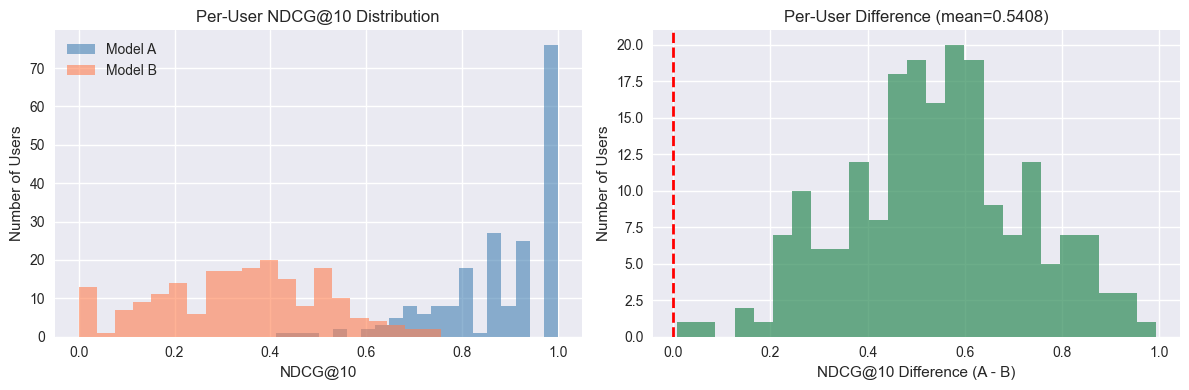

In [13]:
# Visualize per-user metric distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(per_user_ndcg_A, bins=20, alpha=0.6, label='Model A', color='steelblue')
axes[0].hist(per_user_ndcg_B, bins=20, alpha=0.6, label='Model B', color='coral')
axes[0].set_xlabel('NDCG@10')
axes[0].set_ylabel('Number of Users')
axes[0].set_title('Per-User NDCG@10 Distribution')
axes[0].legend()

diffs = per_user_ndcg_A - per_user_ndcg_B
axes[1].hist(diffs, bins=25, color='seagreen', alpha=0.7)
axes[1].axvline(x=0, color='red', linestyle='--', linewidth=2)
axes[1].set_xlabel('NDCG@10 Difference (A - B)')
axes[1].set_ylabel('Number of Users')
axes[1].set_title(f'Per-User Difference (mean={diffs.mean():.4f})')

plt.tight_layout()
plt.show()

## 6. Exercises

### Exercise 1: Build a Comprehensive Evaluation Framework

Build a class `RecEvaluator` that takes recommendations and ground truth and computes all metrics in one call.

In [14]:
# 🏋️ Exercise 1: Comprehensive Evaluation Framework

class RecEvaluator:
    """Comprehensive offline evaluation framework for recommendation systems."""
    
    def __init__(self, ground_truth, num_items, item_features=None, item_popularity=None):
        self.ground_truth = ground_truth
        self.num_items = num_items
        self.item_features = item_features
        self.item_popularity = item_popularity
    
    def evaluate(self, recommendations, k=10):
        """Compute all metrics and return as a dictionary."""
        # TODO: Implement this method
        # It should return a dict with keys:
        # 'NDCG@K', 'MAP@K', 'MRR@K', 'HitRate@K',
        # 'Coverage', 'Gini', 'Diversity', 'Novelty'
        results = {}
        
        # --- YOUR CODE HERE ---
        # results['NDCG@K'] = ...
        # results['MAP@K'] = ...
        # results['MRR@K'] = ...
        # results['HitRate@K'] = ...
        # results['Coverage'] = ...
        # results['Gini'] = ...
        # results['Diversity'] = ...  (if item_features is available)
        # results['Novelty'] = ...    (if item_popularity is available)
        # --- END YOUR CODE ---
        
        return results
    
    def compare(self, recs_a, recs_b, k=10, metric='NDCG'):
        """Compare two models using statistical tests."""
        # TODO: Compute per-user metric for both models,
        # run paired t-test and Wilcoxon test, return summary
        
        # --- YOUR CODE HERE ---
        pass
        # --- END YOUR CODE ---

# Test your implementation:
# evaluator = RecEvaluator(ground_truth, NUM_ITEMS, item_features, item_popularity)
# print(evaluator.evaluate(recs_A, k=10))
# print(evaluator.compare(recs_A, recs_B, k=10))

### Exercise 2: Explore Metric Sensitivity to K

In [15]:
# 🏋️ Exercise 2: Metric Sensitivity Analysis
#
# TODO: For K in [1, 3, 5, 10, 20, 50], compute NDCG@K and Coverage@K
# for both models. Generate recommendations with K=50 first.
# Plot the results and answer:
#   1. At what K does Model B's coverage surpass Model A's?
#   2. Does the NDCG gap widen or narrow as K increases?

# --- YOUR CODE HERE ---
# recs_A_50 = generate_recommendations(ground_truth, NUM_ITEMS, 50, ...)
# recs_B_50 = generate_recommendations(ground_truth, NUM_ITEMS, 50, ...)
# ...
# --- END YOUR CODE ---

### Exercise 3: Implement Serendipity

In [16]:
# 🏋️ Exercise 3: Serendipity Metric
#
# Serendipity measures relevant items that a simple baseline would NOT
# have recommended. Typically:
#   Serendipity = (1/K) * sum_{i in rec} rel(i) * (1 - in_baseline(i))
#
# TODO:
# 1. Implement a popularity baseline that recommends the top-K most popular items to all users
# 2. Compute serendipity for Model A and Model B
# 3. Which model is more serendipitous?

# --- YOUR CODE HERE ---

# --- END YOUR CODE ---

## Summary

In this notebook we covered:

- **Ranking metrics** (NDCG@K, MAP@K, MRR, HitRate@K) — each captures a different aspect of ranking quality
- **Beyond-accuracy metrics** (Coverage, Diversity, Novelty, Serendipity) — essential for user satisfaction
- **Evaluation protocols** — temporal split is preferred for production; leave-one-out is common in research
- **Statistical testing** — always test whether metric differences are significant before drawing conclusions

**Key takeaway:** No single metric tells the full story. A comprehensive evaluation framework should combine accuracy and beyond-accuracy metrics, use proper splitting protocols, and verify results with statistical tests.